In [2]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [3]:
# =========================
# Cell 1: Setup & Paths
# =========================
import os, random, math, time, json
from pathlib import Path

try:
    from google.colab import drive
    IN_COLAB = True
except:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')

# ---- Configure your project root on Drive ----
BASE_DRIVE_DIR = "/content/drive/MyDrive/CSE499A_Project"
WEEK3_DIR      = f"{BASE_DRIVE_DIR}/Week3"
INPUTS_DIR     = f"{WEEK3_DIR}/inputs"        # put a few images here for quick tests
RESULTS_DIR    = f"{WEEK3_DIR}/results"
LOGS_DIR       = f"{WEEK3_DIR}/logs"
CKPT_DIR       = f"{WEEK3_DIR}/checkpoints"

for d in [BASE_DRIVE_DIR, WEEK3_DIR, INPUTS_DIR, RESULTS_DIR, LOGS_DIR, CKPT_DIR]:
    os.makedirs(d, exist_ok=True)

print("Project paths:")
print("BASE_DRIVE_DIR:", BASE_DRIVE_DIR)
print("WEEK3_DIR     :", WEEK3_DIR)
print("INPUTS_DIR    :", INPUTS_DIR)
print("RESULTS_DIR   :", RESULTS_DIR)
print("LOGS_DIR      :", LOGS_DIR)
print("CKPT_DIR      :", CKPT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project paths:
BASE_DRIVE_DIR: /content/drive/MyDrive/CSE499A_Project
WEEK3_DIR     : /content/drive/MyDrive/CSE499A_Project/Week3
INPUTS_DIR    : /content/drive/MyDrive/CSE499A_Project/Week3/inputs
RESULTS_DIR   : /content/drive/MyDrive/CSE499A_Project/Week3/results
LOGS_DIR      : /content/drive/MyDrive/CSE499A_Project/Week3/logs
CKPT_DIR      : /content/drive/MyDrive/CSE499A_Project/Week3/checkpoints


In [4]:
# =========================
# Cell 2: Installs (light)
# =========================
# Colab already has torch/torchvision. Install einops for cleaner tensor ops if needed.
!pip -q install einops==0.8.0

import torch, torchvision
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from einops import rearrange

print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("Device name:", torch.cuda.get_device_name(0))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.2/43.2 kB 1.8 MB/s eta 0:00:00
Torch: 2.8.0+cu126
Torchvision: 0.23.0+cu126
CUDA available: False
Device count: 0


In [5]:
# =========================
# Cell 3: Reproducibility
# =========================
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(123)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [18]:
# =========================
# Cell 4: Transforms & Dataset Loader
# =========================
IMG_SIZE = 256

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])  # to [-1, 1]
])

# Option A: Use a simple ImageFolder at INPUTS_DIR (put images under INPUTS_DIR/anyclass/)
# e.g., /Week3/inputs/sample/your_images.jpg
if not any(Path(INPUTS_DIR).iterdir()):
    # if folder empty, create a tiny sample structure and drop a placeholder note
    os.makedirs(f"{INPUTS_DIR}/sample", exist_ok=True)
    note = os.path.join(INPUTS_DIR, "README.txt")
    with open(note, "w") as f:
        f.write("Put a few images under /Week3/inputs/sample/ for quick tests.\n")

dataset = datasets.ImageFolder(root=INPUTS_DIR, transform=transform)
if len(dataset) == 0:
    print("⚠️ No images found. Add a few images under", f"{INPUTS_DIR}/sample")
else:
    print(f"Found {len(dataset)} images.")

loader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=2, pin_memory=True if device.type=='cuda' else False)


Found 2 images.


In [12]:
# =========================
# Cell 5: Simple Mask Generators (stubs for Week 5)
# =========================
def random_rectangle_mask(b, h=IMG_SIZE, w=IMG_SIZE, min_frac=0.2, max_frac=0.6):
    masks = []
    for _ in range(b):
        mh = np.random.uniform(min_frac, max_frac) * h
        mw = np.random.uniform(min_frac, max_frac) * w
        y0 = np.random.randint(0, int(h - mh))
        x0 = np.random.randint(0, int(w - mw))
        mask = np.zeros((h, w), dtype=np.float32)
        mask[y0:y0+int(mh), x0:x0+int(mw)] = 1.0
        masks.append(mask)
    masks = np.stack(masks, 0)  # [B, H, W]
    return torch.tensor(masks)

def coarse_brush_mask(b, h=IMG_SIZE, w=IMG_SIZE, strokes=5):
    # Very simple coarse strokes—good enough for scaffolding
    masks = np.zeros((b, h, w), dtype=np.float32)
    for i in range(b):
        img = masks[i]
        for _ in range(strokes):
            y, x = np.random.randint(0, h), np.random.randint(0, w)
            lh, lw = np.random.randint(h//16, h//6), np.random.randint(w//16, w//6)
            img[max(0,y-lh):min(h,y+lh), max(0,x-lw):min(w,x+lw)] = 1.0
    return torch.tensor(masks)

# quick test
m = random_rectangle_mask(2)
print("Mask shape:", m.shape, "min/max:", m.min().item(), m.max().item())


Mask shape: torch.Size([2, 256, 256]) min/max: 0.0 1.0


In [13]:
# =========================
# Cell 6: Baseline U-Net (Week 3)
# - Ready for Week 5: set IN_CH=4 to accept [RGB + mask]
# =========================
def conv3x3(in_ch, out_ch):
    return nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)

class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.GroupNorm(8, ch), nn.SiLU(),
            conv3x3(ch, ch),
            nn.GroupNorm(8, ch), nn.SiLU(),
            conv3x3(ch, ch),
        )
    def forward(self, x):
        return x + self.block(x)

class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = conv3x3(in_ch, out_ch)
        self.res  = ResBlock(out_ch)
        self.pool = nn.Conv2d(out_ch, out_ch, kernel_size=4, stride=2, padding=1)  # downsample
    def forward(self, x):
        x = self.conv(x)
        x = self.res(x)
        skip = x
        x = self.pool(x)
        return x, skip

class Up(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1)
        self.res  = ResBlock(out_ch)
        self.mix  = conv3x3(out_ch*2, out_ch)  # to merge skip
    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        x = self.mix(x)
        x = self.res(x)
        return x

class UNetSmall(nn.Module):
    def __init__(self, in_ch=3, out_ch=3, base=64):
        super().__init__()
        self.enc1 = Down(in_ch, base)         # 256 -> 128
        self.enc2 = Down(base, base*2)        # 128 -> 64
        self.enc3 = Down(base*2, base*4)      # 64  -> 32
        self.mid  = nn.Sequential(conv3x3(base*4, base*8), nn.SiLU(), ResBlock(base*8))
        self.up3  = Up(base*8, base*4)
        self.up2  = Up(base*4, base*2)
        self.up1  = Up(base*2, base)
        self.head = nn.Sequential(
            nn.GroupNorm(8, base), nn.SiLU(),
            conv3x3(base, out_ch)
        )

    def forward(self, x):
        x1, s1 = self.enc1(x)
        x2, s2 = self.enc2(x1)
        x3, s3 = self.enc3(x2)
        x4 = self.mid(x3)
        x  = self.up3(x4, s3)
        x  = self.up2(x,  s2)
        x  = self.up1(x,  s1)
        return self.head(x)

# Instantiate (choose in_ch = 3 for plain autoencoder; 4 later for [RGB+mask])
IN_CH = 3   # set to 4 in Week-5
model = UNetSmall(in_ch=IN_CH, out_ch=3, base=64).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(model.__class__.__name__, "params:", f"{n_params/1e6:.2f}M")


UNetSmall params: 15.05M


In [20]:
# =========================
# Cell 7: Quick Sanity Forward + Visualization
# =========================
def denorm(x):
    return (x.clamp(-1,1) + 1) * 0.5

def show_grid(imgs, title=""):
    # imgs: [B,3,H,W] in [-1,1]
    b = min(imgs.shape[0], 4)
    fig, axes = plt.subplots(1, b, figsize=(4*b, 4))
    for i in range(b):
        axes[i].imshow(denorm(imgs[i]).permute(1,2,0).cpu().numpy())
        axes[i].axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    return fig

# Take a small batch and run through untrained model
if len(dataset) > 0:
    batch = next(iter(loader))[0].to(device)  # ignore labels
    with torch.no_grad():
        out = model(batch)
    fig_in = show_grid(batch, "Input (Normalized)")
    fig_out = show_grid(out, "UNet Output (Untrained)")
    in_path  = os.path.join(RESULTS_DIR, "week3_input_preview.png")
    out_path = os.path.join(RESULTS_DIR, "week3_unet_untrained_output.png")
    fig_in.savefig(in_path, dpi=120); plt.close(fig_in)
    fig_out.savefig(out_path, dpi=120); plt.close(fig_out)
    print(f"Saved previews to:\n{in_path}\n{out_path}")
else:
    print("Add images to inputs/ and re-run this cell to see previews.")


Saved previews to:
/content/drive/MyDrive/CSE499A_Project/Week3/results/week3_input_preview.png
/content/drive/MyDrive/CSE499A_Project/Week3/results/week3_unet_untrained_output.png


In [15]:
# =========================
# Cell 9: Save Model Weights (definition checkpoint)
# =========================
save_path = os.path.join(CKPT_DIR, "week3_unet_small_init.pt")
torch.save({"model_state_dict": model.state_dict(),
            "config": {"in_ch": IN_CH, "out_ch": 3, "base": 64, "img_size": IMG_SIZE}}, save_path)
print("Saved initial UNet weights to:", save_path)


Saved initial UNet weights to: /content/drive/MyDrive/CSE499A_Project/Week3/checkpoints/week3_unet_small_init.pt


In [16]:
# =========================
# Cell 10: Notes for Week-4/6 (scaffolding)
# (not executed—just stored for you as a reference JSON)
# =========================
notes = {
  "week4_todo": [
    "Implement beta schedules (linear or cosine).",
    "Forward diffusion: q(x_t | x_{t-1}) & q(x_t | x_0).",
    "Add noise sampler and prepare (x_t, t) conditioning."
  ],
  "week5_todo": [
    "Switch input to concat(masked_image, mask) as in_ch=4.",
    "Train objective to predict noise or x0 (choose one)."
  ],
  "week6_todo": [
    "Train small subset, log losses and sample previews per N steps.",
    "Tune LR, batch size, schedule; consider EMA on weights."
  ]
}
with open(os.path.join(LOGS_DIR, "week3_notes.json"), "w") as f:
    json.dump(notes, f, indent=2)
print("Wrote:", os.path.join(LOGS_DIR, "week3_notes.json"))


Wrote: /content/drive/MyDrive/CSE499A_Project/Week3/logs/week3_notes.json


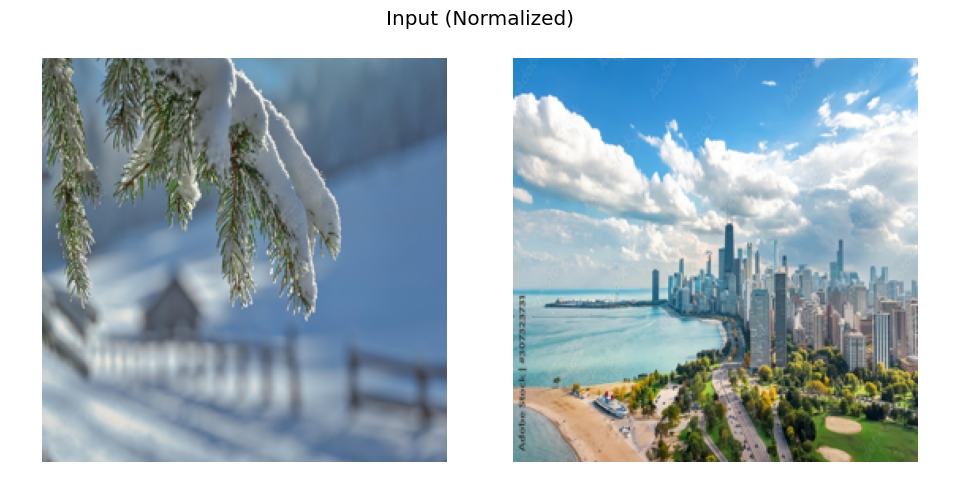

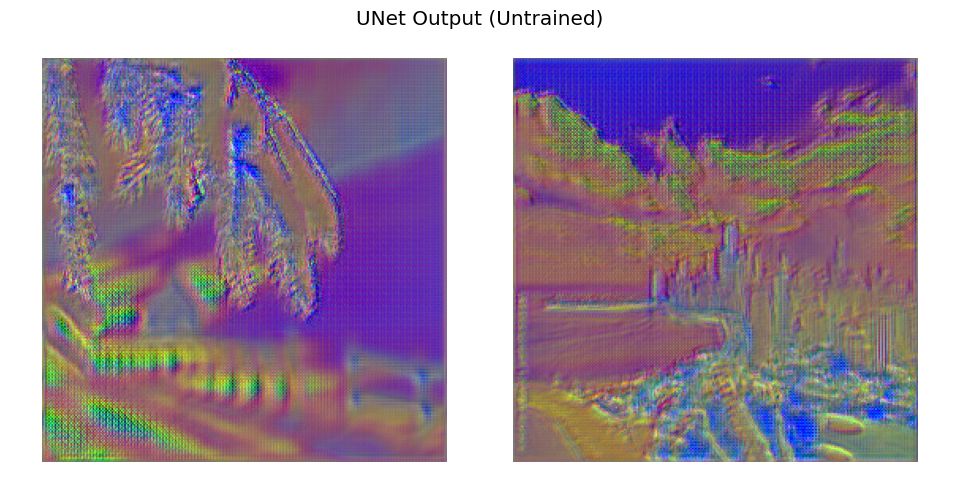

In [21]:
from IPython.display import Image, display

# input and untrained U-Net output
display(Image("/content/drive/MyDrive/CSE499A_Project/Week3/results/week3_input_preview.png"))
display(Image("/content/drive/MyDrive/CSE499A_Project/Week3/results/week3_unet_untrained_output.png"))
